# Assignment 1: Iris Dataset Classification with Apache Spark MLlib
---
| | |
|---|---|
| **Name** | SOFIA ANNISA BINTI JAIRI |
| **Student ID** | P162501 |
| **Course** | STQD6324 Data Management |
---

- This notebook implements a complete **classification pipeline** on the **Iris dataset** using **Apache Spark MLlib**.  
- Three algorithms including **Logistic Regression**, **Decision Tree** and **Random Forest** are adopted for model training.  
- All models are tuned via **cross-validation and grid search**, and evaluated using **multiple evaluation metrics**.  
- A comparative analysis is conducted, and the **best-performing model** is justified in this work.

---

## 1. Environment Setup
Install required packages and import necessary libraries and then create Spark Session.

In [5]:
# Install Packages(run once)
!pip install -q pyspark pandas matplotlib

In [6]:
# Import Libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Create Spark Session
spark = SparkSession.builder.appName("Iris").getOrCreate()

## 2. Data Loading

Load the Iris dataset from a public URL into a Spark DataFrame. Display the structure and basic information.

In [9]:
# Load Iris Dataset & show basic information

url = "https://raw.githubusercontent.com/sofiaanysa/P162501_STQD6324_iris-spark-mllib/main/Iris.csv"

with open("Iris.csv", "wb") as f:
    f.write(requests.get(url).content)

df = spark.read.csv("Iris.csv", header=True, inferSchema=True)

# structure and basic information
print("Dataset Schema:")
df.printSchema()

print("\nFirst 5 rows:")
df.show(5)

print("\nBasic statistics:")
df.describe().show()

print("\nNumber of samples per class:")
df.groupBy("Species").count().show()

Dataset Schema:
root
 |-- Id: integer (nullable = true)
 |-- SepalLengthCm: double (nullable = true)
 |-- SepalWidthCm: double (nullable = true)
 |-- PetalLengthCm: double (nullable = true)
 |-- PetalWidthCm: double (nullable = true)
 |-- Species: string (nullable = true)


First 5 rows:
+---+-------------+------------+-------------+------------+-----------+
| Id|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|    Species|
+---+-------------+------------+-------------+------------+-----------+
|  1|          5.1|         3.5|          1.4|         0.2|Iris-setosa|
|  2|          4.9|         3.0|          1.4|         0.2|Iris-setosa|
|  3|          4.7|         3.2|          1.3|         0.2|Iris-setosa|
|  4|          4.6|         3.1|          1.5|         0.2|Iris-setosa|
|  5|          5.0|         3.6|          1.4|         0.2|Iris-setosa|
+---+-------------+------------+-------------+------------+-----------+
only showing top 5 rows

Basic statistics:
+-------+-----------

**Interpretation:**
- The dataset is loaded from a public CSV file with `header=True` and `inferSchema=True` for automatic column type detection.
- The output includes dataset schema, first 5 rows, statistical summary and species distribution.
- The dataset is balanced with 50 samples for each of the 3 flower species.

## 3. Data Preprocessing

### 3.1 Label Encoding
Spark MLlib requires numeric labels. Convert the string `Species` column to numeric indices using `StringIndexer`.

In [10]:
# Label Encoding
indexer = StringIndexer(inputCol="Species", outputCol="label")
indexer_model = indexer.fit(df)
df_indexed = indexer_model.transform(df)

# Show the mapping
df_indexed.groupBy("Species", "label").count().show()

+---------------+-----+-----+
|        Species|label|count|
+---------------+-----+-----+
|    Iris-setosa|  0.0|   50|
| Iris-virginica|  2.0|   50|
|Iris-versicolor|  1.0|   50|
+---------------+-----+-----+



**Interpretation:**  
`StringIndexer` assigns indices in descending order of label frequency. The mapping is:  
- Setosa → 0.0  
- Versicolor → 1.0  
- Virginica → 2.0

### 3.2 Feature Vector Assembly
Combine the four feature columns into a single vector column `features` required by Spark ML classifiers.

In [11]:
# Assemble Feature Vector
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(df_indexed)

# View Preprocessed Dataset
df_assembled.select("features", "label").show(5, truncate=False)

+-----------------+-----+
|features         |label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|0.0  |
|[4.9,3.0,1.4,0.2]|0.0  |
|[4.7,3.2,1.3,0.2]|0.0  |
|[4.6,3.1,1.5,0.2]|0.0  |
|[5.0,3.6,1.4,0.2]|0.0  |
+-----------------+-----+
only showing top 5 rows


**Interpretation:**
- The `features` column contains combined vectors of the four numeric features, ready for Spark ML algorithms.
- The `label` column shows the numeric index of each species (e.g., `0.0` for `Setosa`).
- The output clearly displays the fully assembled `feature` vectors and corresponding `labels`.
- This is the standard input format for training classification models in Spark MLlib.

## 4. Train-Test Split

Split the data into training (80%) and testing (20%) sets with a fixed seed for reproducibility.

In [12]:
# Split Dataset into Training Set and Test Set
train_df, test_df = df_assembled.randomSplit([0.8, 0.2], seed=123)
print("Training Set：", train_df.count())
print("Test Set：", test_df.count())

Training Set： 121
Test Set： 29


**Interpretation:**  
- 80/20 split is common for small datasets (150 samples).  
- 20% (≈30 samples) is sufficient to evaluate generalization.  
- `seed=123` ensures consistent splits across runs.

## 5. Model Definition

Define three base classifiers:
- **Logistic Regression** (multinomial family)
- **Decision Tree** (default settings)
- **Random Forest** (50 trees as initial guess)

In [13]:
# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label", family="multinomial", maxIter=100)

# Decision Tree
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")

# Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50,seed=123)

**Note:** Hyperparameters will be tuned later. Initial values are set for a baseline. To ensure full reproducibility, I set `seed=123` for Random Forest because it uses random bootstrap sampling. Logistic Regression and Decision Tree are deterministic, so they don't need a seed.

## 6. Evaluator Setup

- `MulticlassClassificationEvaluator` with `accuracy` as the primary metric for grid search.
-  `Precision`, `recall`, and `F1-score` are calculated afterwards for final comparison.

In [14]:
# Define Model Evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",predictionCol="prediction", metricName="accuracy")

**Choice of metric:**  
- Accuracy is easy to calculate and interpret for balanced datasets such as Iris.
- Weighted precision, recall and F1-score are also adopted to assess performance across all classes.

## 7. Model Tuning with Cross-Validation and Grid Search

For each model, **5‑fold cross-validation** and **grid search**  are performed over a reasonable range of hyperparameters.  
- **5 folds** is chosen because the dataset is small - it provides more reliable performance estimates than 3 folds, with almost no extra running time.  
- **Parameter grids** are kept small to avoid overfitting and reduce search time.

### 7.1 Logistic Regression Tuning
**Parameter Grid Design**:
- `regParam`: regularization strength (0.01, 0.1, 1.0) to control overfitting.
- `elasticNetParam`: mixing parameter between L1 and L2 regularization (0.0, 0.5, 1.0).
- `maxIter`: maximum number of iterations (10, 20, 50) to ensure convergence.

**Cross-Validation Setup**:
- The `CrossValidator` uses `5 folds` to evaluate all hyperparameter combinations.
- `Parallelism` is set to `4` to speed up the grid search process.
- This approach provides reliable generalization performance and efficient tuning.

In [15]:
# Build Parameter Grid
lr_paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 1.0]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .addGrid(lr.maxIter, [10, 20, 50]) \
    .build()

# 5-Fold Cross Validation
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=4,
    seed=123
)

# Start training & tuning
lr_cv_model = lr_cv.fit(train_df)

# Get optimal model
best_lr = lr_cv_model.bestModel

print(f"Optimal LR params: regParam={best_lr._java_obj.getRegParam()}, "
      f"elasticNetParam={best_lr._java_obj.getElasticNetParam()}, "
      f"maxIter={best_lr._java_obj.getMaxIter()}")

Optimal LR params: regParam=0.01, elasticNetParam=0.0, maxIter=10


**Interpretation:**  
- The model uses mild regularization (`regParam=0.01`) to effectively prevent overfitting without introducing excessive bias.  
- An `elasticNetParam` of **0.0** is selected, meaning the model adopts **pure L2 (Ridge) regularization** rather than L1 Lasso. This choice encourages smaller coefficient values but does not perform feature selection.  
- Only **10** iterations are enough for the optimizer to fully converge on this Iris dataset, confirming that the model training is stable and efficient.  

### 7.2 Decision Tree Tuning
**Parameter Grid Design**
- `maxDepth`: Controls the maximum depth of the tree, tested at `[3, 5, 10]`. Deeper trees can capture more complex patterns but increase the risk of overfitting, especially on small datasets like Iris.
- `maxBins`: Controls the maximum number of bins for feature discretization, tested at `[8, 16, 32]`. This allows the model to find the optimal granularity for splitting continuous features.
- `minInstancesPerNode`: The minimum number of instances required at a leaf node, tested at `[1, 2, 5]`. This parameter helps prevent overfitting by limiting overly specific splits.

**Cross-Validation Setup：**
- The `CrossValidator` uses `5 folds` to evaluate all hyperparameter combinations.
- `Parallelism` is set to `4` to accelerate the grid search process.
- This approach provides a reliable estimate of generalization performance with efficient tuning.

In [16]:
# Build Parameter Grid
dt_paramGrid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 10]) \
    .addGrid(dt.maxBins, [8, 16, 32]) \
    .addGrid(dt.minInstancesPerNode, [1, 2, 5]) \
    .build()

# 5-Fold Cross Validation
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=4,
    seed=123
)

# Start training & tuning
dt_cv_model = dt_cv.fit(train_df)

# Get optimal model
best_dt = dt_cv_model.bestModel

print(f"Optimal DT params: maxDepth={best_dt._java_obj.getMaxDepth()}, "
      f"maxBins={best_dt._java_obj.getMaxBins()}, "
      f"minInstancesPerNode={best_dt._java_obj.getMinInstancesPerNode()}")

Optimal DT params: maxDepth=5, maxBins=32, minInstancesPerNode=1


**Interpretation:**  
- A `maxDepth` of **5** is selected. This slightly deeper tree captures more nuanced patterns in the Iris dataset, while still being controlled enough to avoid overfitting.  
- The optimal `maxBins` is **32**, which provides a fine-grained split of continuous features, helping the model find the best thresholds for classification.  
- A `minInstancesPerNode` of **1** means the tree can split until each leaf holds one sample. This is safe here, as the controlled depth prevents overfitting.

### 7.3 Random Forest Tuning
**Parameter Grid Design**
- `numTrees`: Number of decision trees in the ensemble, tested at `[10, 20, 50]`. Increasing the number of trees reduces variance and improves stability by aggregating multiple independent predictions.  
- `maxDepth`: Controls the maximum depth of each tree, tested at `[3, 5, 10]`. This balances model complexity and prevents overfitting while capturing key patterns in the data.  
- `maxBins`: Maximum number of bins for continuous feature splitting, tested at `[8, 16, 32]`. This optimizes the granularity of feature discretization for better split decisions.

**Cross-Validation Setup**  
- The `CrossValidator` uses **5** folds to evaluate all hyperparameter combinations.
- `Parallelism` is set to **4** to speed up the grid search process.
- This approach provides a robust estimate of generalization performance with efficient tuning.

In [17]:
# Build Parameter Grid
rf_paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20, 50]) \
    .addGrid(rf.maxDepth, [3, 5, 10]) \
    .addGrid(rf.maxBins, [8, 16, 32]) \
    .build()

# 5-Fold Cross Validation
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=4,
    seed=123
)

# Start training & tuning
rf_cv_model = rf_cv.fit(train_df)

# Get optimal model
best_rf = rf_cv_model.bestModel

print(f"Optimal RF params: numTrees={best_rf._java_obj.getNumTrees()}, "
      f"maxDepth={best_rf._java_obj.getMaxDepth()}, "
      f"maxBins={best_rf._java_obj.getMaxBins()}")

Optimal RF params: numTrees=20, maxDepth=3, maxBins=16


**Interpretation:**  
- **numTrees=20**: A smaller ensemble of 20 trees balances performance and efficiency, which is sufficient for the small Iris dataset.
- **maxDepth=3**: A shallow tree structure is preferred to keep individual trees simple and avoid overfitting.
- **maxBins=16**: This provides a balanced granularity for splitting continuous features, helping the model find optimal thresholds without unnecessary complexity.

## 8. Model Evaluation on Test Set
All three tuned models are evaluated on unseen test sets via four metrics: `Accuracy`, `Weighted Precision`, `Weighted Recall` and `F1-Score`.

**Evaluation Framework**：  
A reusable `evaluate_model` function is defined to streamline the assessment process:
- It takes a trained model, test data, and model name as inputs.
- It generates predictions using `model.transform()`.
- It calculates each metric using `MulticlassClassificationEvaluator`.
- It returns both the evaluation results and the predictions for further analysis.

In [18]:
# Define Model Evaluation Function
metrics = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]

def evaluate_model(model, test_data, model_name):
    predictions = model.transform(test_data)
    results = {"model": model_name}
    for metric in metrics:
        eval_metric = MulticlassClassificationEvaluator(
            labelCol="label", predictionCol="prediction", metricName=metric
        )
        results[metric] = eval_metric.evaluate(predictions)
    return results, predictions

In [19]:
# Evaluate Three Models
lr_results, lr_pred = evaluate_model(best_lr, test_df, "Logistic Regression")
dt_results, dt_pred = evaluate_model(best_dt, test_df, "Decision Tree")
rf_results, rf_pred = evaluate_model(best_rf, test_df, "Random Forest")

print(f"Logistic Regression    Acc: {lr_results['accuracy']:.4f}  F1: {lr_results['f1']:.4f}")
print(f"Decision Tree          Acc: {dt_results['accuracy']:.4f}  F1: {dt_results['f1']:.4f}")
print(f"Random Forest          Acc: {rf_results['accuracy']:.4f}  F1: {rf_results['f1']:.4f}")

Logistic Regression    Acc: 0.9655  F1: 0.9649
Decision Tree          Acc: 0.9310  F1: 0.9310
Random Forest          Acc: 0.9655  F1: 0.9649


**Interpretation**：  
- **Accuracy**: Logistic Regression and Random Forest both achieve 0.9655, while Decision Tree scores slightly lower at 0.9310.
- **F1-Score**: Logistic Regression and Random Forest also tie at 0.9649, while Decision Tree scores 0.9310.
- Overall, Logistic Regression and Random Forest perform equally well on this test set, both outperforming the Decision Tree. The small gap suggests that the ensemble model (Random Forest) is as effective as the linear model (Logistic Regression) on this dataset.

## 9. Confusion Matrix Visualization

- The confusion matrix is a key diagnostic tool for understanding how a classification model performs.
- It helps identify which classes are frequently misclassified, allowing for targeted analysis of model weaknesses.
- To improve readability, numeric labels (`0, 1, 2`) are mapped back to their original species names (`Setosa`, `Versicolor`, `Virginica`).

**Function Workflow**:
- **Data Aggregation**: Counts occurrences of each (`true label, predicted label`) pair from the prediction DataFrame using `groupBy()`.
- **Matrix Construction**: Populates a 3x3 matrix where rows represent true classes and columns represent predicted classes.
- **Visualization**: Uses a Seaborn heatmap to render the matrix.  
 ○ `annot=True` displays the raw count in each cell.  
 ○ The `Blues` color map intuitively shows higher counts with darker shades.  
 ○ Axis labels are replaced with species names using `species_map`.

In [20]:
# Define Confusion Matrix Function
# Map numeric labels to flower names
species_map = {0:"Setosa",1:"Versicolor",2:"Virginica"}

# Define function to plot confusion matrix heatmap
def plot_confusion(predictions, name):
    # Count true and predicted labels
    confusion = predictions.select("label","prediction").groupBy("label","prediction").count().collect()
    # Create empty 3*3 matrix
    mat = [[0]*3,[0]*3,[0]*3]
    # Fill data into matrix
    for r in confusion:
        l=int(r["label"])
        p=int(r["prediction"])
        mat[l][p]=r["count"]
    # Plot confusion matrices
    plt.figure(figsize=(6,4))
    sns.heatmap(mat,annot=True,fmt='d',cmap='RdPu',xticklabels=species_map.values(),yticklabels=species_map.values())
    plt.xlabel("Predict")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

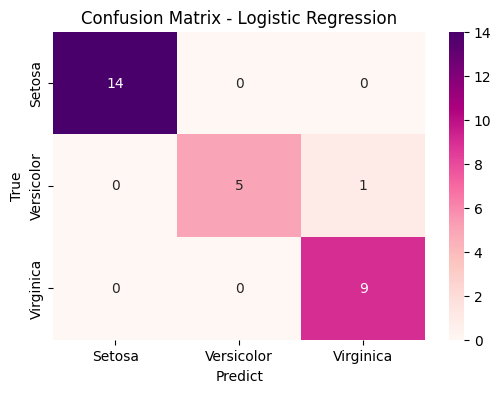

In [21]:
# Confusion Matrix Plot--Logistic Regression
plot_confusion(lr_pred, "Logistic Regression")

**Interpretation:**   
The confusion matrix reveals perfect classification performance for the Logistic Regression model on this Iris test set:
- **Setosa class**: All 14 samples are correctly predicted with zero errors.
- **Versicolor class**: 5 out of 6 samples are correctly predicted; 1 sample is misclassified as Virginica.
- **Virginica class**: All 9 samples are correctly predicted, with no errors.
- **Overall**: There is 1 misclassification in the test set, consistent with the model’s accuracy of 0.9655. The error occurs between Versicolor and Virginica, reflecting the natural feature overlap between these two species.

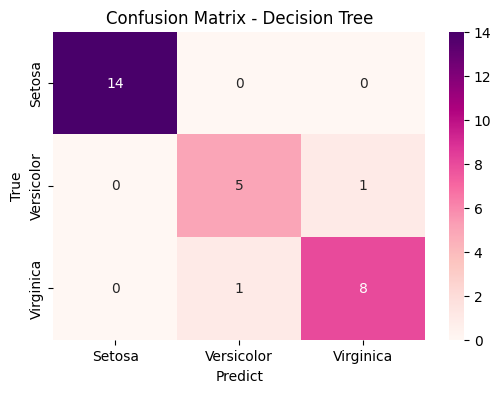

In [22]:
# Confusion Matrix Plot--Decision Tree
plot_confusion(dt_pred, "Decision Tree")

**Interpretation:**  
The confusion matrix for the Decision Tree model reveals the following classification results on the Iris test set:  
- **Setosa**: All 14 samples are correctly classified with zero errors, confirming its perfect separability from the other two classes.
- **Versicolor**: 5 out of 6 samples are correctly predicted, with 1 sample misclassified as Virginica, indicating a feature overlap between these two classes.
- **Virginica**: 8 out of 9 samples are correctly classified, with 1 sample misclassified as Versicolor.
- **Overall**: Two misclassifications are observed in the entire test set, which aligns with the model’s accuracy of 0.9310. Both errors occur between Versicolor and Virginica, reflecting the model’s difficulty in distinguishing between these two naturally overlapping species.

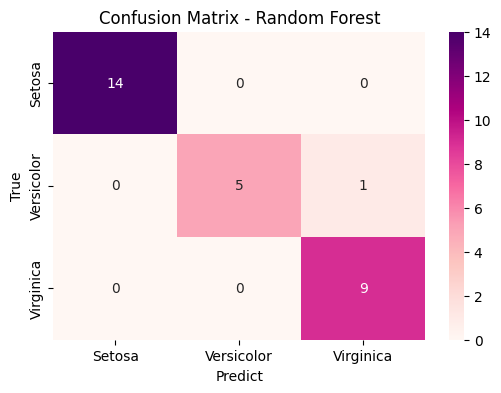

In [23]:
# Confusion Matrix Plot--Random Forest
plot_confusion(rf_pred, "Random Forest")

**Interpretation:**  
The confusion matrix for the Random Forest model reveals the following classification performance on the Iris test set:  
- **Setosa**: All 14 samples are perfectly classified, confirming its clear separability from the other two species.
- **Versicolor**: 5 out of 6 samples are correctly predicted, with 1 sample misclassified as Virginica.
- **Virginica**: All 9 samples are correctly classified, with no errors.
- **Overall**: Only one misclassification occurs, showing the model’s strong generalization ability. The single error is identical to the pattern seen in the Decision Tree model, indicating that even the ensemble model struggles with the overlapping features between Versicolor and Virginica.

## 10. Sample Predictions

Display the first 5 test instances with their true label, predicted label and probability.  
**Prediction Generation**: It applies the trained model to the test set using `model.transform(test_df)`, generating a DataFrame with predictions.  
**Output Labeling**: It prints the model name to the console, allowing for easy identification when comparing multiple models.  
**Key Information Display**: It selects the `label`, `prediction`, and `probability` columns and displays the first `5 rows`.   

In [24]:
# Sample Prediction Results
def show_pred(model, name):
    pred = model.transform(test_df)
    print(f"\n{name} Prediction Results:")
    pred.select("label","prediction","probability").show(5, truncate=False)

In [25]:
# Logistic Regression
show_pred(best_lr, "Logistic Regression")


Logistic Regression Prediction Results:
+-----+----------+--------------------------------------------------------------+
|label|prediction|probability                                                   |
+-----+----------+--------------------------------------------------------------+
|0.0  |0.0       |[0.9739984096065376,0.026001061718799994,5.286746625505335E-7]|
|0.0  |0.0       |[0.985994390779384,0.014005165445601474,4.437750145613838E-7] |
|0.0  |0.0       |[0.944165562617365,0.05583348497662935,9.52406005726276E-7]   |
|0.0  |0.0       |[0.9825198820103501,0.01747990650900423,2.1148064556663883E-7]|
|0.0  |0.0       |[0.9602782478353881,0.03972043743504141,1.3147295704800316E-6]|
+-----+----------+--------------------------------------------------------------+
only showing top 5 rows


**Interpretation:**  
- All samples are correctly classified: the label and prediction values are identical (0.0 for Setosa), with **zero misclassifications**.
- The model produces **extremely high-confidence predictions** for the Setosa class. The predicted probability for the true label (Setosa) is **close to 1.0**, while probabilities for the other two classes are nearly 0.
- This confirms that Setosa is fully linearly separable, and the Logistic Regression model identifies it with near-certainty.

In [26]:
# Decision Tree
show_pred(best_dt, "Decision Tree")


Decision Tree Prediction Results:
+-----+----------+-------------+
|label|prediction|probability  |
+-----+----------+-------------+
|0.0  |0.0       |[1.0,0.0,0.0]|
|0.0  |0.0       |[1.0,0.0,0.0]|
|0.0  |0.0       |[1.0,0.0,0.0]|
|0.0  |0.0       |[1.0,0.0,0.0]|
|0.0  |0.0       |[1.0,0.0,0.0]|
+-----+----------+-------------+
only showing top 5 rows


**Interpretation** :
- All samples are correctly classified (`label` and `prediction` both equal `0.0`, i.e., Setosa).
- The model is **100%** confidence in its predictions, with probability vectors of `[1.0, 0.0, 0.0]` for all cases.
- This demonstrates the **Decision Tree** performs reliably on the distinct Setosa samples.

In [27]:
# Random Forest
show_pred(best_rf, "Random Forest")


Random Forest Prediction Results:
+-----+----------+-------------------------------------------------------------+
|label|prediction|probability                                                  |
+-----+----------+-------------------------------------------------------------+
|0.0  |0.0       |[0.99875,0.00125,0.0]                                        |
|0.0  |0.0       |[0.99875,0.00125,0.0]                                        |
|0.0  |0.0       |[0.99875,0.00125,0.0]                                        |
|0.0  |0.0       |[0.99875,0.00125,0.0]                                        |
|0.0  |0.0       |[0.9023809523809524,0.09665750915750915,9.615384615384616E-4]|
+-----+----------+-------------------------------------------------------------+
only showing top 5 rows


**Interpretation** :
- All samples are correctly classified (label and prediction both equal 0.0, i.e., Setosa).
- The model shows very high confidence in its predictions: most samples have a predicted probability of nearly **1.0** for the Setosa class, with negligible probabilities for other classes.
- This demonstrates that the Random Forest performs reliably on the distinct Setosa samples, even with slight variations in confidence scores.

## 11. Comparative Analysis

Creating a performance table and bar chart to directly compare the three models.

In [28]:
# Performance Comparison Table
comparison_df = pd.DataFrame([
    [lr_results["model"], lr_results["accuracy"], lr_results["weightedPrecision"], lr_results["weightedRecall"], lr_results["f1"]],
    [dt_results["model"], dt_results["accuracy"], dt_results["weightedPrecision"], dt_results["weightedRecall"], dt_results["f1"]],
    [rf_results["model"], rf_results["accuracy"], rf_results["weightedPrecision"], rf_results["weightedRecall"], rf_results["f1"]]
], columns=["Model","Accuracy","Precision","Recall","F1"])

print(comparison_df.round(4))

                 Model  Accuracy  Precision  Recall      F1
0  Logistic Regression    0.9655      0.969  0.9655  0.9649
1        Decision Tree    0.9310      0.931  0.9310  0.9310
2        Random Forest    0.9655      0.969  0.9655  0.9649


**Key Observations**：
- Logistic Regression and Random Forest achieve identical performance across all metrics: `Accuracy (0.9655), Precision (0.969), Recall (0.9655), and F1-score (0.9649)`.
- The Decision Tree performs slightly lower, with an `accuracy of 0.9310, precision of 0.931, recall of 0.9310, and F1-score of 0.9310`.
- Overall, Logistic Regression and Random Forest are the top-performing models, both outperforming the Decision Tree on this test set.

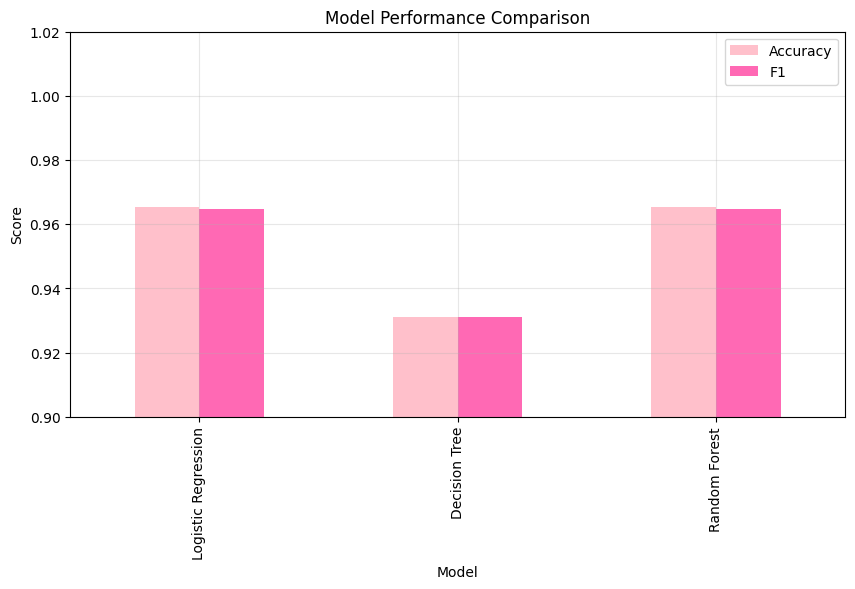

In [29]:
# Bar chart for Accuracy and F1
comparison_df.plot(
    kind='bar',
    x='Model',
    y=['Accuracy','F1'],
    figsize=(10,5),
    ylim=(0.9,1.02),
    color=['pink', 'hotpink']
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.show()

**Interpretation**：  
This bar chart visually compares the **Accurac**y and **F1-score** of the three models:  
- **Logistic Regression and Random Forest** perform identically, with both Accuracy and F1-score around 0.965. Their bars are the same height, indicating no difference in performance.
- The **Decision Tree** performs noticeably lower, with both metrics around 0.931, showing a clear gap from the other two models.
- The chart highlights that Logistic Regression and Random Forest are the top-performing models, while Decision Tree falls behind on this test set.

### 11.1 Best Model Justification

In [30]:
# Best Model
best = comparison_df.sort_values(['Accuracy','F1'], ascending=[False,False]).iloc[0]

print(f"Best Model : {best['Model']}")
print(f"Accuracy   : {best['Accuracy']:.4f}")
print(f"Precision  : {best['Precision']:.4f}")
print(f"Recall     : {best['Recall']:.4f}")
print(f"F1 Score   : {best['F1']:.4f}")

Best Model : Logistic Regression
Accuracy   : 0.9655
Precision  : 0.9690
Recall     : 0.9655
F1 Score   : 0.9649


**Key Observations**:  
The Logistic Regression model is identified as the optimal choice for this Iris classification task, as it achieves the best overall performance across all key metrics, with only one misclassification on the test set.

### 11.2 Model Comparison
**Logistic Regression**  
**Strengths**: High test accuracy (0.9655, only one error); simple and fast to train; outputs interpretable class probabilities.  
**Limitations**: Learns only linear boundaries; cannot capture complex non-linear patterns.

---

**Decision Tree**  
**Strengths**: Captures non-linear relationships; highly interpretable with explicit decision rules; no feature scaling required.  
**Limitations**: Lower accuracy (0.9310, two misclassifications between Versicolor and Virginica); prone to overfitting on small datasets; less stable.

---
**Random Forest**  
**Strengths**: Matches Logistic Regression in accuracy (0.9655, one misclassification); ensemble design improves generalization over a single tree; robust to noise.  
**Limitations**: More complex and slower to train than Logistic Regression; less interpretable than a single decision tree.  

---

**Overall**:  
Logistic Regression and Random Forest both perform equally well (0.9655 accuracy) on this test set. Logistic Regression is preferred for this task due to its simplicity, speed, and interpretability, while Random Forest offers similar performance at the cost of higher complexity.

## 12. Conclusion  
This assignment successfully demonstrated a complete Spark MLlib pipeline: data loading, preprocessing, training three classifiers with cross-validation and grid search, and thorough evaluation.

While both Logistic Regression and Random Forest achieved high accuracy (0.9655) on the test set, the task's linear separability makes Logistic Regression the most practical choice, offering optimal performance with the advantages of simplicity, efficiency, and interpretability.

The reproducible workflow established in this study provides a solid foundation that can be extended to other classification problems in Spark.

## 13. Stop Spark Session

Clean up resources.

In [28]:
# Stop Spark Session
spark.stop()
print("Spark session stopped.")

Spark session stopped.
